# Apply — GNN trials (LightGCN)

What was tried before [`src/train_gnn.py`](src/train_gnn.py) got its defaults -> same **1,000-user subset** + same evaluator as `embeddings_trials.ipynb`, so numbers line up with the KGE trials (DistMult there: recall@10 0.179).
LightGCN = MF + neighbour averaging, nothing else -> `layers=0` **is** MF, so every layer added is a clean ablation.

In [1]:
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

sys.path.insert(0, "src")
from recsys_eval import INTERACTIONS, Evaluator, load_split, subset_split
from train_gnn import train

warnings.filterwarnings("ignore", message="Sparse invariant checks")
N_USERS, EPOCHS = 1000, 40
TRIALS = {}

full = load_split()
sp = subset_split(full, N_USERS)
ev = Evaluator(sp)
train_i = sp["train"][sp["train"].r.isin(INTERACTIONS)]
pop = train_i.t.value_counts()
pop_vec = np.array([pop.get(a, 0) for a in ev.candidates], dtype=np.float32)
POP = ev.evaluate(lambda users: np.tile(pop_vec, (len(users), 1)))
print("popularity recall@10", round(POP["recall@10"], 4))

popularity recall@10 0.1226


In [2]:
def run(name, **kw):
    kw = {"epochs": EPOCHS, "eval_every": 5, "patience": 2, "verbose": False} | kw
    out = train(sp, **kw)
    TRIALS[name] = out
    m = out["metrics"]
    print(f"{name:22} recall@10 {m['recall@10']:.4f}  ndcg@10 {m['ndcg@10']:.4f}  best epoch {out['best_epoch']:>2}  ({out['train_seconds']}s)")
    return out

## 1. How many layers? (0 = MF)

In [3]:
for k in range(4):
    run(f"k={k}" + (" (= MF)" if k == 0 else ""), layers=k)

k=0 (= MF)             recall@10 0.1755  ndcg@10 0.1682  best epoch 20  (7s)
k=1                    recall@10 0.2135  ndcg@10 0.2061  best epoch 40  (27s)
k=2                    recall@10 0.2165  ndcg@10 0.2129  best epoch 40  (44s)
k=3                    recall@10 0.2086  ndcg@10 0.2040  best epoch 40  (55s)


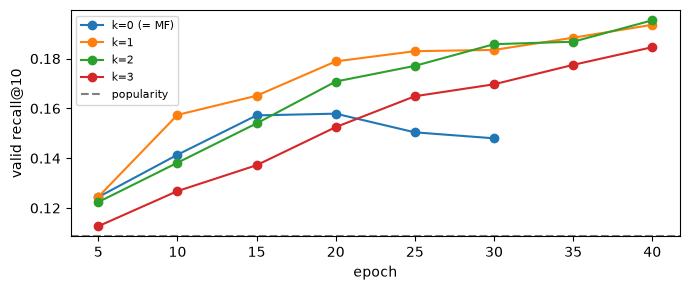

In [4]:
fig, ax = plt.subplots(figsize=(7, 3))
for name, out in TRIALS.items():
    h = np.array(out["history"])
    ax.plot(h[:, 0], h[:, 2], marker="o", label=name)
ax.axhline(ev.evaluate(lambda u: np.tile(pop_vec, (len(u), 1)), on="valid")["recall@10"], ls="--", c="grey", label="popularity")
ax.set_xlabel("epoch"); ax.set_ylabel("valid recall@10"); ax.legend(fontsize=8)
plt.tight_layout()

> k=0 (MF) 0.176 -> k=1 0.214 = +22% from **one** round of neighbour averaging, no new parameters. k=2 0.217, k=3 0.209 -> beyond 1–2 hops ≈ flat (gaps inside noise: one seed, runs still rising at the 40-epoch cap). MF also peaks early (epoch 20) and overfits; propagated models keep improving -> averaging over neighbours smooths the embeddings. Full data agrees: MF 0.196 -> k=3 0.262. -> graph structure is doing the work, so does *more* graph (KG content) help?

## 2. KG content edges inside the GNN

Same k=3, graph now also has anime <-> genre / theme / studio / producer / licensor / source / type / demographic.
LightGCN treats them as plain edges (no relation types).

In [5]:
k3 = TRIALS["k=3"]
k3c = run("k=3 + content", layers=3, content=True)
print(f"graph size: {len(k3['nodes']):,} -> {len(k3c['nodes']):,} nodes")

k=3 + content          recall@10 0.2127  ndcg@10 0.1998  best epoch 40  (168s)
graph size: 7,218 -> 32,279 nodes


> content edges: recall 0.209 -> 0.213 but NDCG 0.204 -> 0.200 -> no real gain for ranking users' anime, at 4.5× the nodes and ~2.3× the time. Contrast with the KGE trials, where content gave +0.013 -> LightGCN already links anime through shared users (anime–user–anime = 2 hops), so genre paths add little a warm anime doesn't already have. -> where content *should* matter = anime with no users at all

## 3. Cold start — anime with zero ratings

In the content graph, anime nobody in the subset interacted with are still nodes (reached via genre/studio) -> they get an embedding only from their neighbours. Are those embeddings meaningful?
Check -> genre overlap (Jaccard) between a cold anime and its 5 nearest *rated* anime, vs random pairs.

In [6]:
titles = pd.read_csv("data/anime.csv", usecols=["mal_id", "title"])
title = dict(zip("anime_" + titles.mal_id.astype(str), titles.title))
tr = sp["train"]
genres = tr[tr.r == "hasGenre"].groupby("h").t.apply(set).to_dict()

nodes, E = k3c["nodes"], k3c["E"]
n2i = {x: i for i, x in enumerate(nodes)}
warm = [a for a in ev.candidates if a in genres]
cold = [x for x in nodes if x.startswith("anime_") and x not in ev.cand_idx and x in genres]
print(f"{len(cold):,} cold anime (content only) vs {len(warm):,} warm candidates")

Ew = torch.nn.functional.normalize(E[[n2i[a] for a in warm]], dim=1)

def neighbours(a, n=5):
    v = torch.nn.functional.normalize(E[n2i[a]], dim=0)
    return [warm[i] for i in (Ew @ v).topk(n).indices.tolist()]

def jac(a, b):
    return len(genres[a] & genres[b]) / len(genres[a] | genres[b])

rng = np.random.default_rng(26)
sample = rng.choice(cold, 500, replace=False)
nn_j = np.mean([jac(a, b) for a in sample for b in neighbours(a)])
rand_j = np.mean([jac(a, b) for a in sample for b in rng.choice(warm, 5)])
print(f"genre Jaccard, cold anime vs 5 nearest warm: {nn_j:.3f} | vs 5 random warm: {rand_j:.3f}")

16,659 cold anime (content only) vs 6,043 warm candidates
genre Jaccard, cold anime vs 5 nearest warm: 0.361 | vs 5 random warm: 0.112


In [7]:
for a in rng.choice(cold, 3, replace=False):
    print(f"{title.get(a, a)}  {sorted(genres[a])}")
    for b in neighbours(a):
        print(f"    -> {title.get(b, b)}  {sorted(genres[b])}")

Sabaku no Kuni no Oujosama  ['Adventure', 'Fantasy']
    -> Hokuto no Ken: Legend of Heroes  ['Action']
    -> Dragon Quest: Dai no Daibouken (TV)  ['Action', 'Adventure', 'Fantasy']
    -> Fushigi na Koala Blinky  ['Adventure', 'Comedy', 'Fantasy']
    -> Black Jack (TV): Hizouban Specials  ['Adventure']
    -> Ring ni Kakero 1: Nichibei Kessen-hen  ['Sports']
Jurassic!  ['Fantasy']
    -> Mahoujin Guruguru Movie  ['Adventure', 'Comedy', 'Fantasy']
    -> Mirai Shounen Conan: Kyodaiki Gigant no Fukkatsu  ['Adventure', 'Drama', 'SciFi']
    -> Dokidoki♡Densetsu: Mahoujin Guruguru  ['Adventure', 'Comedy', 'Fantasy']
    -> Konnichiwa Anne: Before Green Gables  ['Drama']
    -> Shin Mitsubachi Maya no Bouken  ['Adventure', 'Comedy']
Bishoujo Comic Lolicon Angel: Mitsu no Aji  ['Hentai']
    -> Dark Shell: Ori no Naka no Namameki  ['Hentai']
    -> Luv Wave  ['Action', 'Drama', 'Hentai', 'Horror', 'Mystery', 'SciFi']
    -> Advancer Tina  ['Hentai', 'SciFi']
    -> Court no Naka no Tenshi

> cold anime got embeddings purely via genre/studio neighbours and still land next to genre-matching warm anime -> Jaccard 0.361 vs 0.112 random (3.2×). Examples read sensibly (old kids' adventure/fantasy -> Dragon Quest, Mahoujin Guruguru; Hentai -> Hentai). A shallow lookup table (KGE/MF) would have *nothing* for these 16.7k anime without retraining. -> content = coverage, not accuracy

## 4. All trials side by side

In [8]:
rows = {"popularity": POP} | {k: v["metrics"] for k, v in TRIALS.items()}
table = pd.DataFrame(rows).T[["recall@10", "ndcg@10", "hr@10"]].round(4)
table["best epoch"] = [np.nan] + [v["best_epoch"] for v in TRIALS.values()]
table

,recall@10,ndcg@10,hr@10,best epoch
popularity,0.1226,0.1195,0.5026,NaN
k=0 (= MF),0.1755,0.1682,0.6162,20.0
k=1,0.2135,0.2061,0.6898,40.0
k=2,0.2165,0.2129,0.6887,40.0
k=3,0.2086,0.2040,0.6814,40.0
k=3 + content,0.2127,0.1998,0.6824,40.0


## Learning and final decisions

- **Message passing is the big win** -> MF 0.176 -> LightGCN 0.209–0.217 on the subset, 0.196 -> 0.262 on full data. Same embedding table, same loss; the only change is averaging over neighbours.
- **layers = 3 kept** (LightGCN paper default) -> but 1 layer already gives most of the gain and 2/3 are indistinguishable here. The honest statement is "≥1 hop matters, more is not clearly better".
- **Propagation also regularizes** -> MF peaks early and overfits; propagated models kept improving through the epoch cap.
- **KG content in the GNN: no accuracy gain for warm anime, clear gain in coverage.** It helped KGE (+0.013) but not LightGCN, because co-rating already connects anime at 2 hops. Its real value: 16.7k content-only anime get meaningful embeddings (genre Jaccard 3.2× random) -> matters for adding new anime to the graph (-> Learn/04 evolution).
- **Relation types ignored** (an edge is an edge) -> kept deliberately for interpretability. R-GCN / KGAT would type the edges; out of scope given what content added here.
- Caveats: 40-epoch cap (k≥1 still rising), one seed -> small gaps (k=1 vs 2 vs 3, content ±0.004) are not decisions, just "no evidence of a difference".